# Forecasting Illegal Fishing Hotspots in Kenyan Waters Using Machine Learning

This notebook follows a complete end-to-end machine learning pipeline for maritime monitoring, using AIS data and environmental variables.

---

## 1. Problem Definition

The objective is to detect and predict suspicious or illegal fishing behavior from AIS vessel movement and environmental conditions. The model should learn patterns that separate routine vessel traffic from potential fishing operations.

Operational goal: generate patrol-priority hotspots in Kenyan waters to support maritime enforcement planning.

## 2. Data Acquisition and Loading


The AIS vessel activity data used in this study was sourced from the [Global Fishing Watch](https://globalfishingwatch.org/data-download/datasets/vessel-presence/) public datasets platform, which provides open-access global fishing activity data derived from satellite-based Automatic Identification System (AIS) signals. Global Fishing Watch processes raw AIS transmissions from vessels worldwide and combines them with machine learning algorithms to estimate vessel movements and fishing activity patterns. For this project, vessel tracking records covering one year period 2022 were utilized to ensure sufficient temporal coverage for detecting behavioural patterns in maritime activity. The dataset contains vessel identifiers, geographic coordinates, speed, course, timestamps, and related operational indicators that capture vessel movement dynamics over time. This time period was selected to provide a large volume of observations and to reflect recent fishing behaviour patterns in global maritime environments, enabling robust feature engineering and machine learning modelling for detecting suspicious fishing activity.

Dataset used: `ais_vessel_activity.csv`.

Fields include:
- Vessel ID (`mmsi`)
- Position (`latitude`, `longitude`)
- Motion (`speed_knots`, `heading`, `course_over_ground`)
- Time (`timestamp`)
- Context (`distance_from_shore_km`, `sea_surface_temp`, `chlorophyll`, `ais_gap_minutes`)

In [15]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [16]:
data_path = "ais_vessel_activity.csv"
df_raw= pd.read_csv(data_path)
print("Raw shape:", df_raw.shape)

Raw shape: (350000, 11)


## 3. Initial Data Inspection (Eyeballing the Data)

Inspect sample rows, schema, and basic structure before deeper analysis.

In [17]:
display(df_raw.head(10))
display(df_raw.dtypes.to_frame("dtype"))
print("Rows:", len(df_raw), "Columns:", df_raw.shape[1])

,mmsi,latitude,longitude,speed_knots,heading,course_over_ground,timestamp,distance_from_shore_km,sea_surface_temp,chlorophyll,ais_gap_minutes
0,253550572,-19.829774,29.784439,2.09,214,162,2022-01-01 00:00:00,11.77,28.97,2.831,78
1,664373628,22.391071,46.395246,11.89,181,294,2022-01-01 00:01:00,73.31,29.02,3.239,63
2,592742910,-12.013585,32.683020,12.90,315,338,2022-01-01 00:02:00,45.42,21.06,1.580,83
3,463327063,-18.105243,65.520908,4.56,107,192,2022-01-01 00:03:00,185.19,22.83,4.730,32
4,459809140,-24.279870,45.270645,8.89,88,124,2022-01-01 00:04:00,20.06,21.95,4.176,80
5,715158751,8.069414,24.398983,12.94,28,200,2022-01-01 00:05:00,167.85,27.01,1.159,11
6,251567383,-8.852225,35.921857,17.58,197,218,2022-01-01 00:06:00,129.55,29.11,4.141,14
7,618420816,-5.963247,32.390273,3.92,78,247,2022-01-01 00:07:00,156.49,25.99,4.495,100
8,320881721,-8.022468,36.777435,13.62,91,127,2022-01-01 00:08:00,18.74,27.05,0.308,73
9,256506408,-2.951190,54.312273,8.40,95,302,2022-01-01 00:09:00,1.06,29.22,2.752,47


,dtype
mmsi,int64
latitude,float64
longitude,float64
speed_knots,float64
heading,int64
course_over_ground,int64
timestamp,object
distance_from_shore_km,float64
sea_surface_temp,float64
chlorophyll,float64


Rows: 350000 Columns: 11


## 4. Exploratory Data Analysis (EDA)

This section includes descriptive statistics, distribution analysis, spatial analysis, correlation checks, and class balance review.

In [20]:
# Ensure timestamp parsed for temporal analysis
df_eda = df_raw.copy()
df_eda["timestamp"] = pd.to_datetime(df_eda["timestamp"], errors="coerce")

numeric_cols = [
    "latitude", "longitude", "speed_knots", "heading", "course_over_ground",
    "distance_from_shore_km", "sea_surface_temp", "chlorophyll", "ais_gap_minutes"
]
display(df_eda[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
latitude,350000.0,-0.034655,14.426424,-24.999878,-12.535679,-0.057469,12.470388,24.999633
longitude,350000.0,50.043232,17.316551,20.000008,35.038841,50.043412,65.040899,79.999892
speed_knots,350000.0,12.492230,7.208369,0.000000,6.270000,12.470000,18.730000,25.000000
heading,350000.0,179.652454,103.894209,0.000000,90.000000,180.000000,270.000000,359.000000
course_over_ground,350000.0,179.478989,103.912731,0.000000,89.000000,180.000000,269.000000,359.000000
distance_from_shore_km,350000.0,99.965374,57.780400,0.000000,49.927500,99.880000,150.140000,200.000000
sea_surface_temp,350000.0,26.000789,3.460939,20.000000,23.010000,26.000000,29.000000,32.000000
chlorophyll,350000.0,2.549078,1.415051,0.100000,1.324000,2.544000,3.778000,5.000000
ais_gap_minutes,350000.0,59.505494,34.646823,0.000000,29.000000,60.000000,90.000000,119.000000


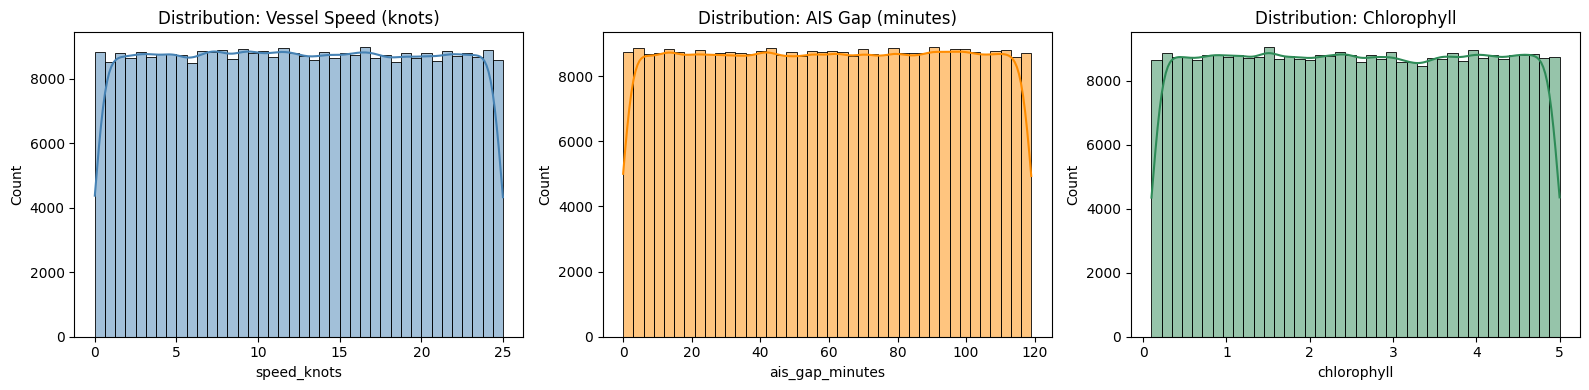

In [19]:
# Distribution analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_eda["speed_knots"], kde=True, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution: Vessel Speed (knots)")

sns.histplot(df_eda["ais_gap_minutes"], kde=True, bins=40, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution: AIS Gap (minutes)")

sns.histplot(df_eda["chlorophyll"], kde=True, bins=40, ax=axes[2], color="seagreen")
axes[2].set_title("Distribution: Chlorophyll")

plt.tight_layout()
plt.show()

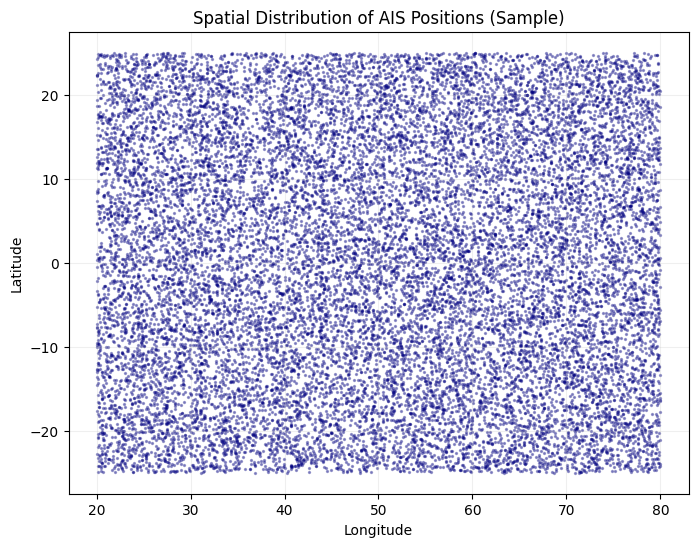

In [13]:
# Spatial analysis (point cloud)
sample_map = df_eda.sample(min(20000, len(df_eda)), random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample_map["longitude"], sample_map["latitude"], s=2, alpha=0.35, c="navy")
plt.title("Spatial Distribution of AIS Positions (Sample)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)
plt.show()

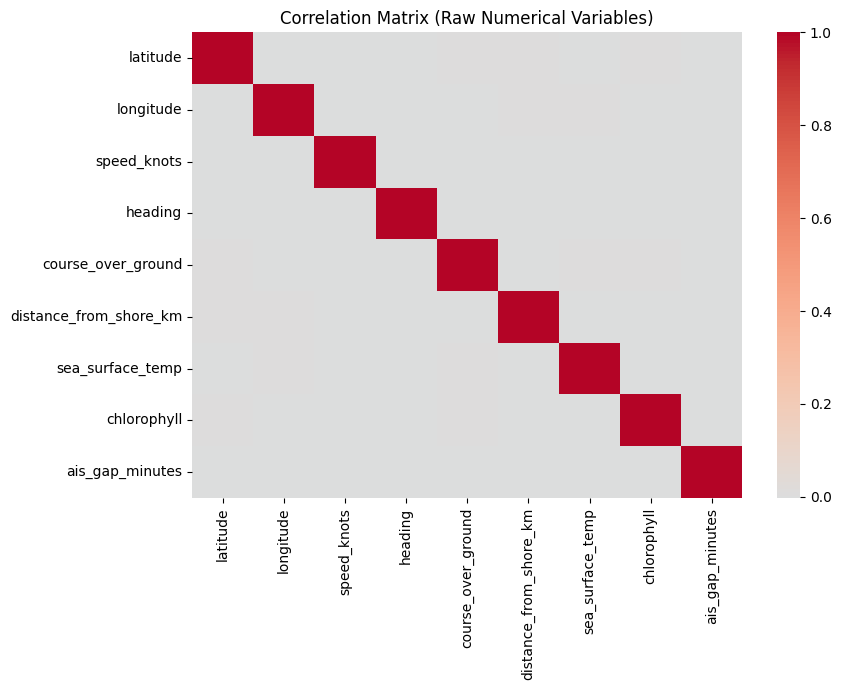

In [21]:
# Correlation analysis
corr = df_eda[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix (Raw Numerical Variables)")
plt.tight_layout()
plt.show()

## 5. Data Cleaning

Cleaning tasks applied:
- Remove duplicates
- Convert timestamp to datetime
- Remove invalid coordinates
- Filter unrealistic speed values
- Keep data in consistent units (already in knots, km, deg C)

In [22]:
df = df_raw.copy()
initial_rows = len(df)

# Remove exact duplicate records
df = df.drop_duplicates()

# Parse timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Valid coordinate bounds
df = df[(df["latitude"].between(-90, 90)) & (df["longitude"].between(-180, 180))]

# Filter unrealistic speed values (knots)
df = df[(df["speed_knots"] >= 0) & (df["speed_knots"] <= 60)]

print("Rows before cleaning:", initial_rows)
print("Rows after cleaning:", len(df))
print("Rows removed:", initial_rows - len(df))

Rows before cleaning: 350000
Rows after cleaning: 350000
Rows removed: 0


## 6. Handling Missing Values

Approach:
- Drop rows missing critical identifiers/time/position
- Keep remaining missing numeric values for model-stage median imputation
- Use `SimpleImputer(strategy='median')` inside each model pipeline

In [23]:
critical_cols = ["mmsi", "timestamp", "latitude", "longitude", "speed_knots", "heading"]
before_missing = len(df)
df = df.dropna(subset=critical_cols)
after_missing = len(df)

print("Rows before missing-value handling:", before_missing)
print("Rows after dropping critical missing values:", after_missing)

missing_table = df.isna().sum().sort_values(ascending=False)
display(missing_table[missing_table > 0].to_frame("missing_count"))

Rows before missing-value handling: 350000
Rows after dropping critical missing values: 350000


,missing_count


## 7. Feature Engineering

The engineered behavior features follow your provided logic:

1. **Vessel Speed Behavior**
- `low_speed_flag`: speed between 1 and 5 knots
- `speed_change`: absolute change from previous speed (per vessel)

2. **Turning Behavior**
- `heading_change`: absolute change from previous heading (per vessel)

3. **Vessel Loitering**
- `movement_distance`: point-to-point distance proxy between AIS pings

4. **AIS Signal Gaps**
- `ais_gap_minutes`: timestamp difference to previous ping (with fallback)

5. **Environmental Productivity**
- `high_productivity_zone`: chlorophyll > 2.5

6. **Distance from Shore**
- `offshore_flag`: distance > 50 km

7. **Composite Fishing Score**
- Sum of behavioral indicators

In [24]:
df = df.sort_values(["mmsi", "timestamp"]).reset_index(drop=True)

# 1) Vessel Speed Behavior
df["low_speed_flag"] = ((df["speed_knots"] >= 1) & (df["speed_knots"] <= 5)).astype(int)
df["speed_change"] = df.groupby("mmsi")["speed_knots"].diff().abs()

# 2) Turning Behavior
df["heading_change"] = df.groupby("mmsi")["heading"].diff().abs()

# 3) Vessel Loitering
df["lat_prev"] = df.groupby("mmsi")["latitude"].shift(1)
df["lon_prev"] = df.groupby("mmsi")["longitude"].shift(1)
df["movement_distance"] = np.sqrt(
    (df["latitude"] - df["lat_prev"]) ** 2 +
    (df["longitude"] - df["lon_prev"]) ** 2
)

# 4) AIS Signal Gaps
df["time_prev"] = df.groupby("mmsi")["timestamp"].shift(1)
df["ais_gap_minutes_calc"] = (df["timestamp"] - df["time_prev"]).dt.total_seconds() / 60
if "ais_gap_minutes" in df.columns:
    df["ais_gap_minutes"] = df["ais_gap_minutes_calc"].fillna(df["ais_gap_minutes"])
else:
    df["ais_gap_minutes"] = df["ais_gap_minutes_calc"]

# 5) Environmental Productivity
df["high_productivity_zone"] = (df["chlorophyll"] > 2.5).astype(int)

# 6) Distance from Shore
df["offshore_flag"] = (df["distance_from_shore_km"] > 50).astype(int)

# Fill lag-based nulls
for c in ["speed_change", "heading_change", "movement_distance", "ais_gap_minutes"]:
    df[c] = df[c].fillna(0)

# 7) Composite Fishing Score
df["fishing_score"] = (
    df["low_speed_flag"] +
    (df["heading_change"] > 30).astype(int) +
    (df["movement_distance"] < 0.01).astype(int) +
    (df["ais_gap_minutes"] > 30).astype(int) +
    df["high_productivity_zone"]
)

display(df[[
    "mmsi", "timestamp", "speed_knots", "speed_change", "heading_change", "movement_distance",
    "ais_gap_minutes", "distance_from_shore_km", "chlorophyll", "fishing_score"
]].head(12))

,mmsi,timestamp,speed_knots,speed_change,heading_change,movement_distance,ais_gap_minutes,distance_from_shore_km,chlorophyll,fishing_score
0,200000522,2022-01-04 10:48:00,18.83,0.0,0.0,0.0,75.0,64.38,4.726,3
1,200001162,2022-06-04 07:42:00,8.35,0.0,0.0,0.0,106.0,91.56,2.675,3
2,200001809,2022-02-03 19:21:00,11.54,0.0,0.0,0.0,9.0,193.82,3.389,2
3,200004832,2022-07-12 22:25:00,0.76,0.0,0.0,0.0,51.0,96.30,4.744,3
4,200007901,2022-01-14 21:18:00,22.51,0.0,0.0,0.0,82.0,50.61,1.890,2
5,200007969,2022-03-27 04:09:00,7.69,0.0,0.0,0.0,58.0,188.19,2.749,3
6,200008800,2022-07-17 14:46:00,13.07,0.0,0.0,0.0,72.0,167.51,3.614,3
7,200009104,2022-04-25 16:00:00,12.82,0.0,0.0,0.0,42.0,129.63,3.888,3
8,200009395,2022-07-11 07:51:00,5.99,0.0,0.0,0.0,78.0,40.05,3.951,3
9,200011050,2022-02-15 17:33:00,20.25,0.0,0.0,0.0,72.0,121.86,2.346,2


## 8. Target Variable Definition

Because explicit illegal fishing labels are not provided, a behavioral heuristic target is constructed:

- `illegal_fishing = 1` if `fishing_score >= 3`
- `illegal_fishing = 0` otherwise

Interpretation:
- `0`: normal vessel activity
- `1`: suspected fishing behavior

,count,proportion
class,,
0,190187,0.543391
1,159813,0.456609


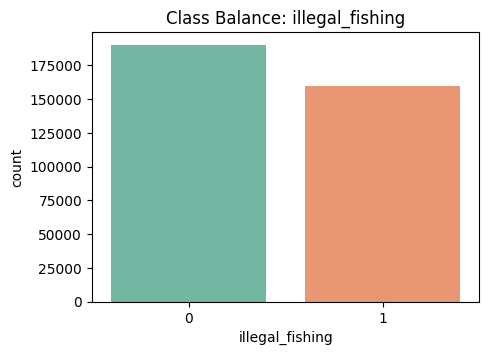

In [25]:
df["illegal_fishing"] = (df["fishing_score"] >= 3).astype(int)

class_balance = df["illegal_fishing"].value_counts().sort_index().rename_axis("class").to_frame("count")
class_balance["proportion"] = class_balance["count"] / class_balance["count"].sum()
display(class_balance)

plt.figure(figsize=(5, 3.5))
sns.countplot(x="illegal_fishing", data=df, palette="Set2")
plt.title("Class Balance: illegal_fishing")
plt.show()

## 9. Feature Selection

Initial candidate features include movement behavior, offshore context, and ocean productivity variables.

Selection checks performed:
- Correlation review to detect potential redundancy
- Prioritization of behavior-based indicators with operational meaning

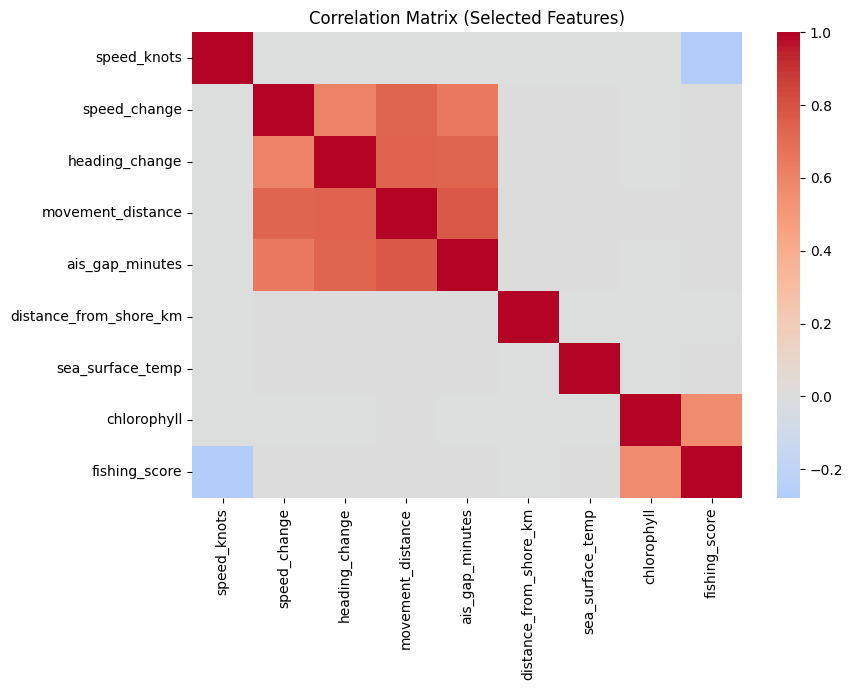

,speed_knots,speed_change,heading_change,movement_distance,ais_gap_minutes,distance_from_shore_km,sea_surface_temp,chlorophyll,fishing_score
speed_knots,1.00,0.00,-0.00,0.00,-0.00,-0.0,-0.0,-0.00,-0.28
speed_change,0.00,1.00,0.60,0.73,0.64,0.0,0.0,0.00,0.00
heading_change,-0.00,0.60,1.00,0.74,0.73,0.0,0.0,-0.00,0.00
movement_distance,0.00,0.73,0.74,1.00,0.77,0.0,0.0,0.00,0.00
ais_gap_minutes,-0.00,0.64,0.73,0.77,1.00,0.0,0.0,0.00,0.01
distance_from_shore_km,-0.00,0.00,0.00,0.00,0.00,1.0,-0.0,0.00,-0.00
sea_surface_temp,-0.00,0.00,0.00,0.00,0.00,-0.0,1.0,-0.00,0.00
chlorophyll,-0.00,0.00,-0.00,0.00,0.00,0.0,-0.0,1.00,0.57
fishing_score,-0.28,0.00,0.00,0.00,0.01,-0.0,0.0,0.57,1.00


In [26]:
feature_cols = [
    "speed_knots",
    "speed_change",
    "heading_change",
    "movement_distance",
    "ais_gap_minutes",
    "distance_from_shore_km",
    "sea_surface_temp",
    "chlorophyll",
    "fishing_score"
]

corr_features = df[feature_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr_features, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Selected Features)")
plt.tight_layout()
plt.show()

display(corr_features.round(2))

## 10. Data Splitting

Use an 80/20 train-test split with stratification to preserve class balance.

In [27]:
X = df[feature_cols].copy()
y = df["illegal_fishing"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train positive rate:", round(y_train.mean(), 4))
print("y_test positive rate:", round(y_test.mean(), 4))

X_train: (280000, 9) X_test: (70000, 9)
y_train positive rate: 0.4566
y_test positive rate: 0.4566


## 11. Model Selection

Four classification models are compared:
- Logistic Regression
- Random Forest
- Gradient Boosting
- Support Vector Machine (SVC)

All models use median imputation. Scaling is applied where appropriate.

In [28]:
models = {
    "LogisticRegression": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=500, class_weight="balanced", random_state=42))
    ]),

    "RandomForest": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=250,
            max_depth=12,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "GradientBoosting": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", GradientBoostingClassifier(random_state=42))
    ]),

    "SVM": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ])
}

## 12. Model Training

Each selected model is trained on the training subset.

In [29]:
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

print("Training complete for", len(fitted_models), "models.")

Training complete for 4 models.


## 13. Model Evaluation

Evaluate on test data using:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

In [31]:
eval_rows = []
predictions_by_model = {}

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    eval_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
    })
    predictions_by_model[name] = (y_pred, y_prob)

evaluation_df = pd.DataFrame(eval_rows).sort_values(["f1", "roc_auc"], ascending=False).reset_index(drop=True)
display(evaluation_df.round(4))


,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,1.0000,1.0000,1.0,1.0000,1.0
1,RandomForest,1.0000,1.0000,1.0,1.0000,1.0
2,GradientBoosting,1.0000,1.0000,1.0,1.0000,1.0
3,SVM,0.9998,0.9996,1.0,0.9998,1.0


Best model selected: LogisticRegression

Classification report:

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     38037
           1     1.0000    1.0000    1.0000     31963

    accuracy                         1.0000     70000
   macro avg     1.0000    1.0000    1.0000     70000
weighted avg     1.0000    1.0000    1.0000     70000



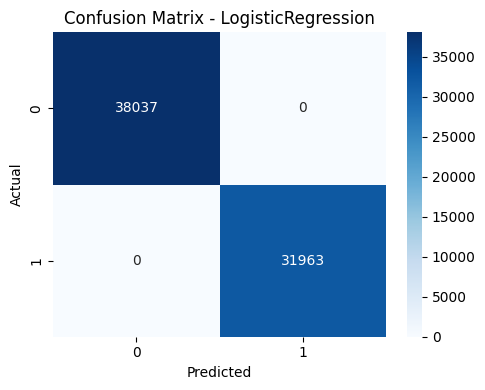

In [32]:
best_model_name = evaluation_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_pred, best_prob = predictions_by_model[best_model_name]

print("Best model selected:", best_model_name)
print("\nClassification report:\n")
print(classification_report(y_test, best_pred, digits=4))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 14. Model Comparison

Compare all models and retain the one with the best balance of detection capability and overall classification quality.

,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,1.0000,1.0000,1.0,1.0000,1.0
1,RandomForest,1.0000,1.0000,1.0,1.0000,1.0
2,GradientBoosting,1.0000,1.0000,1.0,1.0000,1.0
3,SVM,0.9998,0.9996,1.0,0.9998,1.0


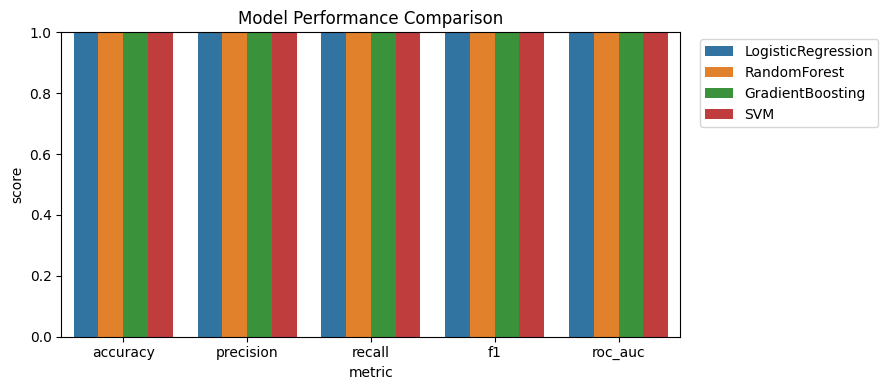

In [33]:
comparison_cols = ["model", "accuracy", "precision", "recall", "f1", "roc_auc"]
display(evaluation_df[comparison_cols].round(4))

plt.figure(figsize=(9, 4))
melted = evaluation_df.melt(id_vars="model", value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"], var_name="metric", value_name="score")
sns.barplot(data=melted, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 15. Output Generation

Generate operational outputs:
- Predicted fishing probability for each AIS record
- Kenya-focused hotspot grid rankings
- Saved output files for reporting/dashboard integration

In [34]:
# Predicted risk for all records
df_output = df.copy()
df_output["predicted_illegal_fishing"] = best_model.predict(df_output[feature_cols])
df_output["predicted_risk"] = best_model.predict_proba(df_output[feature_cols])[:, 1]

# Kenya waters filter (approximate bounding box)
kenya_df = df_output[
    (df_output["latitude"] >= -5.5) & (df_output["latitude"] <= 5.5) &
    (df_output["longitude"] >= 33.0) & (df_output["longitude"] <= 42.5)
].copy()

grid_size = 0.25
kenya_df["lat_bin"] = np.floor(kenya_df["latitude"] / grid_size) * grid_size
kenya_df["lon_bin"] = np.floor(kenya_df["longitude"] / grid_size) * grid_size

hotspots = (
    kenya_df.groupby(["lat_bin", "lon_bin"], as_index=False)
    .agg(
        traffic_points=("mmsi", "size"),
        heuristic_suspected_events=("illegal_fishing", "sum"),
        predicted_suspected_events=("predicted_illegal_fishing", "sum"),
        avg_predicted_risk=("predicted_risk", "mean"),
        avg_chlorophyll=("chlorophyll", "mean"),
        avg_speed=("speed_knots", "mean")
    )
)
hotspots = hotspots.sort_values(["avg_predicted_risk", "predicted_suspected_events"], ascending=[False, False])

display(hotspots.head(20))

,lat_bin,lon_bin,traffic_points,heuristic_suspected_events,predicted_suspected_events,avg_predicted_risk,avg_chlorophyll,avg_speed
1416,3.75,35.75,1,1,1,1.000000,3.228000,1.300000
989,1.00,33.50,2,2,2,0.999938,3.504000,9.595000
71,-5.25,41.25,4,4,4,0.999922,3.385500,7.232500
567,-2.00,41.75,3,3,3,0.999915,4.100667,8.263333
121,-4.75,34.75,1,1,1,0.999911,4.607000,6.700000
977,0.75,40.00,3,3,3,0.999906,3.925000,8.550000
412,-3.00,41.00,4,4,4,0.999906,3.224750,11.972500
903,0.25,40.50,7,7,7,0.999900,3.723571,9.778571
445,-2.75,39.75,2,2,2,0.999900,4.514500,9.560000
515,-2.25,38.25,5,5,5,0.999899,3.388400,7.958000


In [ ]:
# Save key outputs
df_output.to_csv("engineered_illegal_fishing_predictions.csv", index=False)
hotspots.to_csv("kenya_patrol_hotspots.csv", index=False)
evaluation_df.to_csv("model_comparison_results.csv", index=False)

print("Saved output files:")
print("- engineered_illegal_fishing_predictions.csv")
print("- kenya_patrol_hotspots.csv")
print("- model_comparison_results.csv")

## 16. Interpretation and Insights

Example business insight:

> Suspicious fishing behavior is strongly associated with vessels operating at low speeds (1-5 knots), showing high heading variability, exhibiting AIS transmission gaps, and appearing in high-chlorophyll waters.

Patrol relevance:
- Prioritize hotspots with high `avg_predicted_risk`
- Monitor repeated loitering patterns in productive waters
- Flag vessels combining low-speed movement + high turning + long AIS gaps

## 17. Limitations and Future Improvements

### Limitations
- Target variable is heuristic-derived, not enforcement-verified ground truth
- AIS can be incomplete due to outages or deliberate disabling
- Kenya waters are approximated using a bounding box, not official EEZ polygons
- Environmental variables are limited to available fields in this dataset

### Future Improvements
- Integrate confirmed enforcement cases for stronger supervision
- Add satellite data and nighttime lights for dark-vessel detection
- Use precise maritime boundary shapefiles for geofencing
- Introduce temporal sequence models and anomaly detection
- Deploy near-real-time scoring for live patrol decision support